In [1]:
# ============================================================
# Notebook 05 — Análisis nocturno completo
# Simula una noche de 8 horas y calcula el IAH
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import tensorflow as tf
import pickle

np.random.seed(99)

# Cargar modelo y scaler
modelo = tf.keras.models.load_model('../model/mejor_modelo.keras')

with open('../data/simulated/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print("✓ Modelo y scaler cargados")
print(f"✓ Modelo: {modelo.count_params():,} parámetros")

✓ Modelo y scaler cargados
✓ Modelo: 29,891 parámetros


In [2]:
# ============================================================
# Simular una noche completa de 8 horas
# 8 horas × 60 min × 60 seg / 30 seg por ventana = 960 ventanas
# ============================================================

VENTANAS_POR_HORA = 120   # 60min × 60seg / 30seg
HORAS_SUENO      = 8
TOTAL_VENTANAS   = VENTANAS_POR_HORA * HORAS_SUENO  # 960

def generar_noche_simulada(total_ventanas):
    """
    Simula un paciente con apnea leve-moderada.
    La apnea es más frecuente en la segunda mitad de la noche
    — esto es clínicamente real, coincide con las fases REM.
    """
    senales  = []
    etiquetas_reales = []
    t = np.linspace(0, 30, 300)

    for i in range(total_ventanas):
        progreso = i / total_ventanas  # 0.0 a 1.0

        # Primera mitad — mayoría normal con apnea leve ocasional
        if progreso < 0.5:
            prob_normal = 0.85
            prob_leve   = 0.12
            prob_severa = 0.03
        # Segunda mitad — más apneas (fase REM)
        else:
            prob_normal = 0.65
            prob_leve   = 0.25
            prob_severa = 0.10

        clase = np.random.choice([0, 1, 2], 
                                  p=[prob_normal, prob_leve, prob_severa])
        etiquetas_reales.append(clase)

        # Generar señal según clase
        if clase == 0:
            frecuencia = np.random.uniform(12, 20) / 60
            amplitud   = np.random.uniform(0.8, 1.2)
            senal = amplitud * np.sin(2 * np.pi * frecuencia * t)
            senal += np.random.normal(0, 0.05, 300)

        elif clase == 1:
            frecuencia = np.random.uniform(10, 15) / 60
            amplitud   = np.random.uniform(0.6, 1.0)
            senal = amplitud * np.sin(2 * np.pi * frecuencia * t)
            duracion_pausa = np.random.randint(10, 20)
            inicio = np.random.randint(0, 30 - duracion_pausa)
            idx_i  = int(inicio * 300 / 30)
            idx_f  = int((inicio + duracion_pausa) * 300 / 30)
            senal[idx_i:idx_f] = np.random.normal(0, 0.02, idx_f - idx_i)
            senal += np.random.normal(0, 0.05, 300)

        else:
            frecuencia = np.random.uniform(6, 10) / 60
            amplitud   = np.random.uniform(0.3, 0.6)
            senal = amplitud * np.sin(2 * np.pi * frecuencia * t)
            duracion_pausa = np.random.randint(20, 28)
            inicio = np.random.randint(0, 30 - duracion_pausa)
            idx_i  = int(inicio * 300 / 30)
            idx_f  = int((inicio + duracion_pausa) * 300 / 30)
            senal[idx_i:idx_f] = np.random.normal(0, 0.01, idx_f - idx_i)
            senal += np.random.normal(0, 0.05, 300)

        senales.append(senal)

    return np.array(senales), np.array(etiquetas_reales)


X_noche, y_real = generar_noche_simulada(TOTAL_VENTANAS)

print(f"✓ Noche generada: {TOTAL_VENTANAS} ventanas de 30 segundos")
print(f"✓ Distribución real:")
print(f"   Normal:       {(y_real==0).sum()} ventanas ({(y_real==0).sum()/TOTAL_VENTANAS*100:.1f}%)")
print(f"   Apnea leve:   {(y_real==1).sum()} ventanas ({(y_real==1).sum()/TOTAL_VENTANAS*100:.1f}%)")
print(f"   Apnea severa: {(y_real==2).sum()} ventanas ({(y_real==2).sum()/TOTAL_VENTANAS*100:.1f}%)")

✓ Noche generada: 960 ventanas de 30 segundos
✓ Distribución real:
   Normal:       749 ventanas (78.0%)
   Apnea leve:   153 ventanas (15.9%)
   Apnea severa: 58 ventanas (6.0%)


In [3]:
# ============================================================
# Inferencia — el modelo analiza las 960 ventanas
# ============================================================

# Normalizar con el mismo scaler del entrenamiento
X_noche_norm = scaler.transform(X_noche)
X_noche_lstm = X_noche_norm.reshape(X_noche_norm.shape[0], 
                                     X_noche_norm.shape[1], 1)

print("Analizando la noche completa...")

# Predicciones con probabilidades
probabilidades = modelo.predict(X_noche_lstm, verbose=0)
y_pred_noche   = np.argmax(probabilidades, axis=1)

print(f"✓ {TOTAL_VENTANAS} ventanas analizadas")
print(f"\nResultados del modelo:")
print(f"   Normal:       {(y_pred_noche==0).sum()} ventanas ({(y_pred_noche==0).sum()/TOTAL_VENTANAS*100:.1f}%)")
print(f"   Apnea leve:   {(y_pred_noche==1).sum()} ventanas ({(y_pred_noche==1).sum()/TOTAL_VENTANAS*100:.1f}%)")
print(f"   Apnea severa: {(y_pred_noche==2).sum()} ventanas ({(y_pred_noche==2).sum()/TOTAL_VENTANAS*100:.1f}%)")

# Comparar con realidad
correctas = (y_pred_noche == y_real).sum()
print(f"\n✓ Ventanas correctamente clasificadas: {correctas}/{TOTAL_VENTANAS} ({correctas/TOTAL_VENTANAS*100:.1f}%)")

Analizando la noche completa...
✓ 960 ventanas analizadas

Resultados del modelo:
   Normal:       748 ventanas (77.9%)
   Apnea leve:   129 ventanas (13.4%)
   Apnea severa: 83 ventanas (8.6%)

✓ Ventanas correctamente clasificadas: 918/960 (95.6%)


In [4]:
# ============================================================
# Cálculo del IAH
# Índice de Apnea-Hipopnea — métrica clínica estándar
# ============================================================

eventos_apnea = (y_pred_noche == 1).sum() + (y_pred_noche == 2).sum()
IAH = eventos_apnea / HORAS_SUENO

print("=" * 50)
print("   ÍNDICE DE APNEA-HIPOPNEA (IAH)")
print("=" * 50)
print(f"\n   Eventos detectados:  {eventos_apnea}")
print(f"   Horas de sueño:      {HORAS_SUENO}")
print(f"   IAH calculado:       {IAH:.1f} eventos/hora")

print("\n" + "=" * 50)
print("   DIAGNÓSTICO PRELIMINAR")
print("=" * 50)

if IAH < 5:
    nivel    = "SIN APNEA DETECTABLE"
    color    = "✓"
    consejo  = "Tu patrón respiratorio es normal."
elif IAH < 15:
    nivel    = "APNEA LEVE"
    color    = "⚠"
    consejo  = "Se recomienda consultar a un médico."
elif IAH < 30:
    nivel    = "APNEA MODERADA"
    color    = "⚠⚠"
    consejo  = "Consulta a un especialista del sueño."
else:
    nivel    = "APNEA SEVERA"
    color    = "✗"
    consejo  = "Busca atención médica pronto."

print(f"\n   {color} {nivel}")
print(f"   IAH: {IAH:.1f} eventos/hora")
print(f"   {consejo}")
print(f"\n   NOTA: Este es un diagnóstico preliminar.")
print(f"   No sustituye la evaluación médica profesional.")
print("=" * 50)

   ÍNDICE DE APNEA-HIPOPNEA (IAH)

   Eventos detectados:  212
   Horas de sueño:      8
   IAH calculado:       26.5 eventos/hora

   DIAGNÓSTICO PRELIMINAR

   ⚠⚠ APNEA MODERADA
   IAH: 26.5 eventos/hora
   Consulta a un especialista del sueño.

   NOTA: Este es un diagnóstico preliminar.
   No sustituye la evaluación médica profesional.


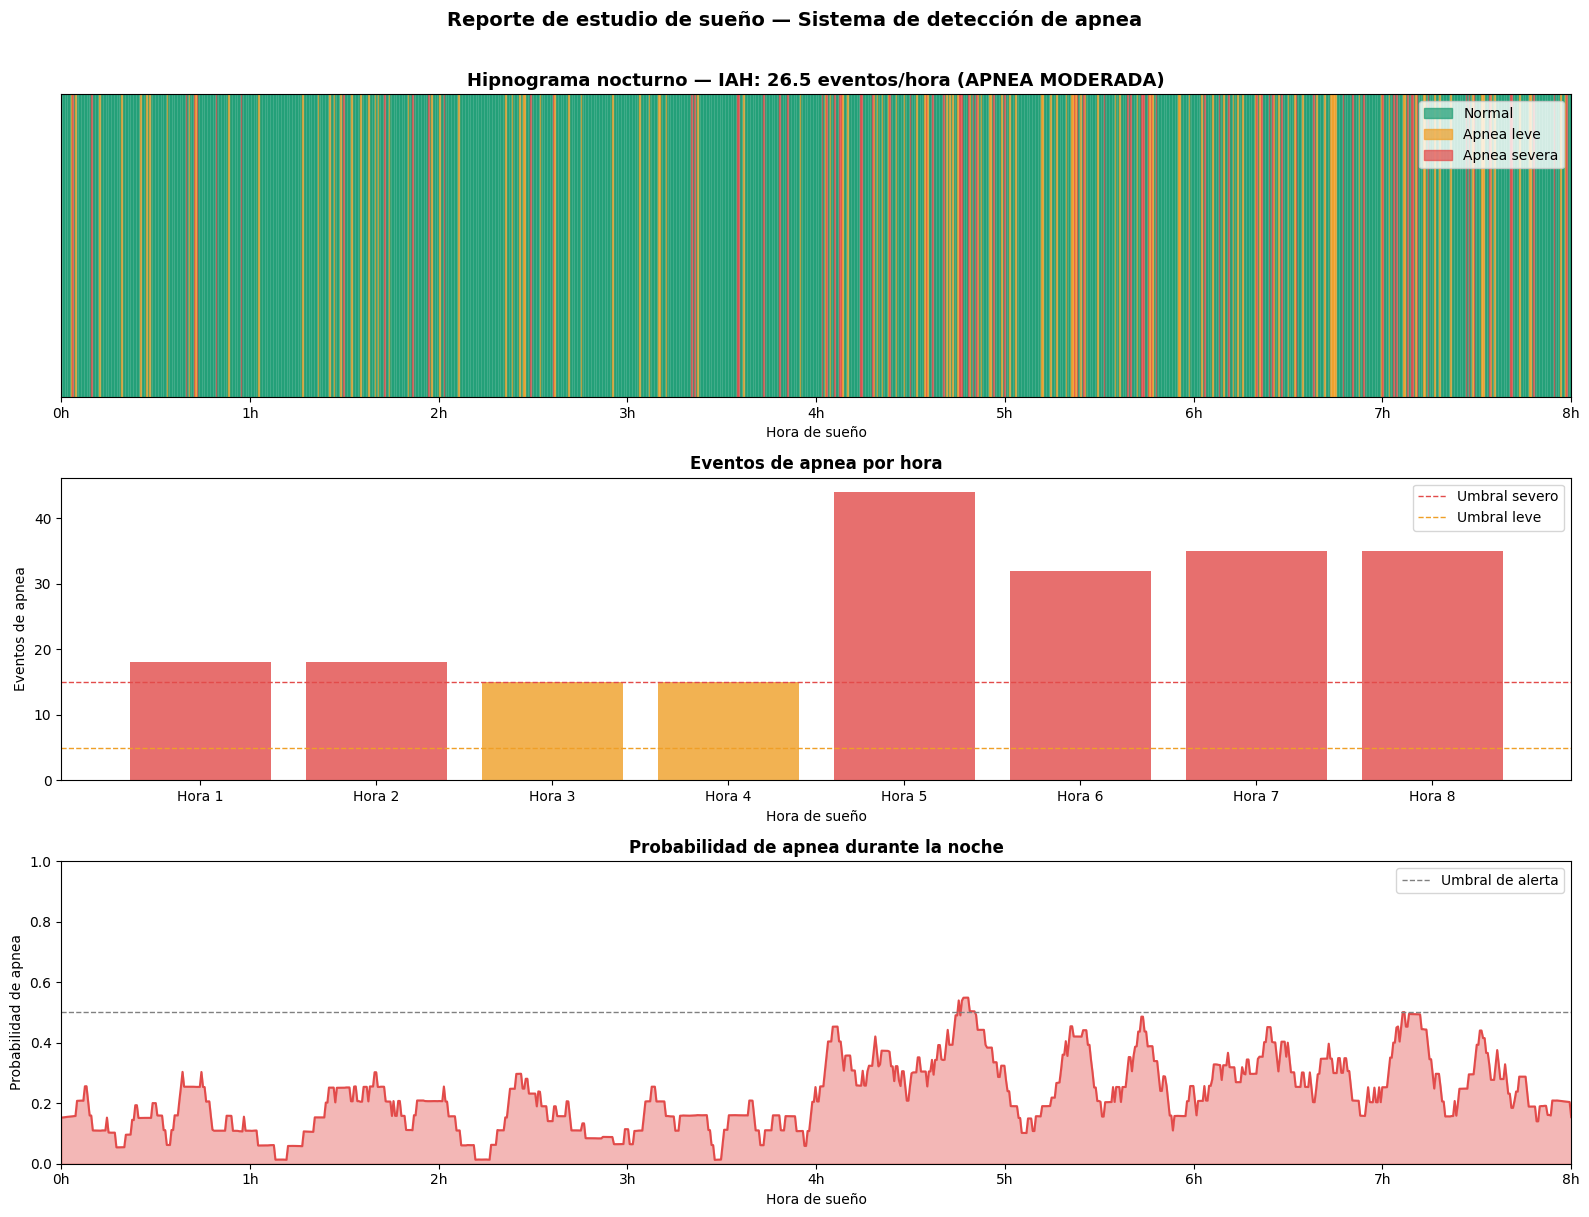

✓ Reporte nocturno guardado en data/simulated/reporte_nocturno.png


In [5]:
# ============================================================
# Hipnograma — gráfica de la noche completa
# Es exactamente lo que verá el paciente en la app
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
horas = np.linspace(0, 8, TOTAL_VENTANAS)

# --- Gráfica 1: Hipnograma completo ---
colores_ventana = []
for pred in y_pred_noche:
    if pred == 0:
        colores_ventana.append('#1D9E75')
    elif pred == 1:
        colores_ventana.append('#EF9F27')
    else:
        colores_ventana.append('#E24B4A')

for i in range(TOTAL_VENTANAS):
    axes[0].axvspan(horas[i], horas[i] + 8/TOTAL_VENTANAS,
                    color=colores_ventana[i], alpha=0.7)

axes[0].set_xlim(0, 8)
axes[0].set_ylim(0, 1)
axes[0].set_xlabel('Hora de sueño')
axes[0].set_title(f'Hipnograma nocturno — IAH: {IAH:.1f} eventos/hora ({nivel})',
                   fontweight='bold', fontsize=13)
axes[0].set_yticks([])
axes[0].set_xticks(range(9))
axes[0].set_xticklabels([f'{h}h' for h in range(9)])

parche_normal = mpatches.Patch(color='#1D9E75', alpha=0.7, label='Normal')
parche_leve   = mpatches.Patch(color='#EF9F27', alpha=0.7, label='Apnea leve')
parche_severa = mpatches.Patch(color='#E24B4A', alpha=0.7, label='Apnea severa')
axes[0].legend(handles=[parche_normal, parche_leve, parche_severa],
               loc='upper right')

# --- Gráfica 2: Eventos por hora ---
eventos_por_hora = []
for h in range(HORAS_SUENO):
    inicio = h * VENTANAS_POR_HORA
    fin    = inicio + VENTANAS_POR_HORA
    eventos = ((y_pred_noche[inicio:fin] == 1).sum() + 
               (y_pred_noche[inicio:fin] == 2).sum())
    eventos_por_hora.append(eventos)

barras = axes[1].bar(range(HORAS_SUENO), eventos_por_hora,
                      color=['#E24B4A' if e > 15 else '#EF9F27' if e > 5 
                             else '#1D9E75' for e in eventos_por_hora],
                      alpha=0.8, edgecolor='none')
axes[1].axhline(y=15, color='#E24B4A', linestyle='--', 
                linewidth=1, label='Umbral severo')
axes[1].axhline(y=5,  color='#EF9F27', linestyle='--', 
                linewidth=1, label='Umbral leve')
axes[1].set_xlabel('Hora de sueño')
axes[1].set_ylabel('Eventos de apnea')
axes[1].set_title('Eventos de apnea por hora', fontweight='bold')
axes[1].set_xticks(range(HORAS_SUENO))
axes[1].set_xticklabels([f'Hora {h+1}' for h in range(HORAS_SUENO)])
axes[1].legend()

# --- Gráfica 3: Probabilidad de apnea a lo largo de la noche ---
prob_apnea = probabilidades[:, 1] + probabilidades[:, 2]
ventanas_suavizado = 20
prob_suave = np.convolve(prob_apnea, 
                          np.ones(ventanas_suavizado)/ventanas_suavizado, 
                          mode='same')

axes[2].fill_between(horas, prob_suave, alpha=0.4, color='#E24B4A')
axes[2].plot(horas, prob_suave, color='#E24B4A', linewidth=1.5)
axes[2].axhline(y=0.5, color='gray', linestyle='--', 
                linewidth=1, label='Umbral de alerta')
axes[2].set_xlim(0, 8)
axes[2].set_ylim(0, 1)
axes[2].set_xlabel('Hora de sueño')
axes[2].set_ylabel('Probabilidad de apnea')
axes[2].set_title('Probabilidad de apnea durante la noche', fontweight='bold')
axes[2].set_xticks(range(9))
axes[2].set_xticklabels([f'{h}h' for h in range(9)])
axes[2].legend()

plt.suptitle('Reporte de estudio de sueño — Sistema de detección de apnea',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/simulated/reporte_nocturno.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("✓ Reporte nocturno guardado en data/simulated/reporte_nocturno.png")